# Libraries

In [63]:
import numpy as np
import scipy
from scipy import signal, fft
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import math

# root = str(Path().resolve().parent)
custom_pkg = str(Path().resolve().parent.parent / "python")
if custom_pkg not in sys.path:
    sys.path.append(custom_pkg)
print(*sys.path, sep="\n")

# %matplotlib ipympl
%matplotlib inline

/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/home/ryanwtsai/repos/rfdsp_sim/python/venv/lib/python3.12/site-packages
/home/ryanwtsai/repos/rfdsp_sim/python


In [2]:
from importlib import reload
from rfdsppy import calc, ofdm, rf_analog, rf_tx_fw, \
    tonegen, digital_filter_design, digital_hw_algo as dighw, \
    rf_estimation as rf_est

reload(calc)
reload(ofdm)
reload(rf_analog)
reload(rf_tx_fw)
reload(tonegen)
reload(digital_filter_design)
reload(dighw)
reload(rf_est)

<module 'rfdsppy.rf_estimation' from '/home/ryanwtsai/repos/rfdsp_sim/python/rfdsppy/rf_estimation.py'>

# Periodogram for uniform white noise

This example is from Discrete-Time Signal Processing (Oppenheim) Section 10.5.2.

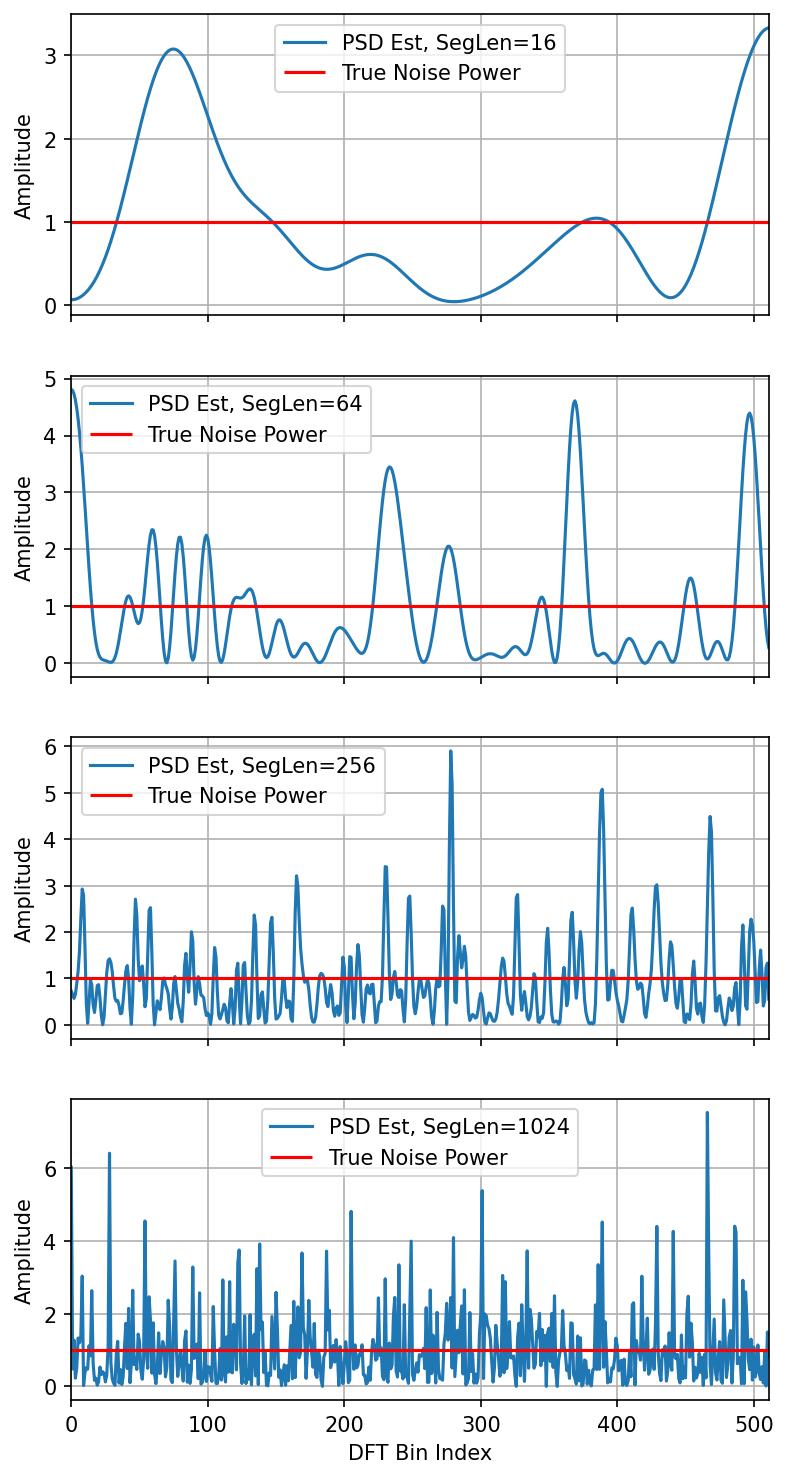

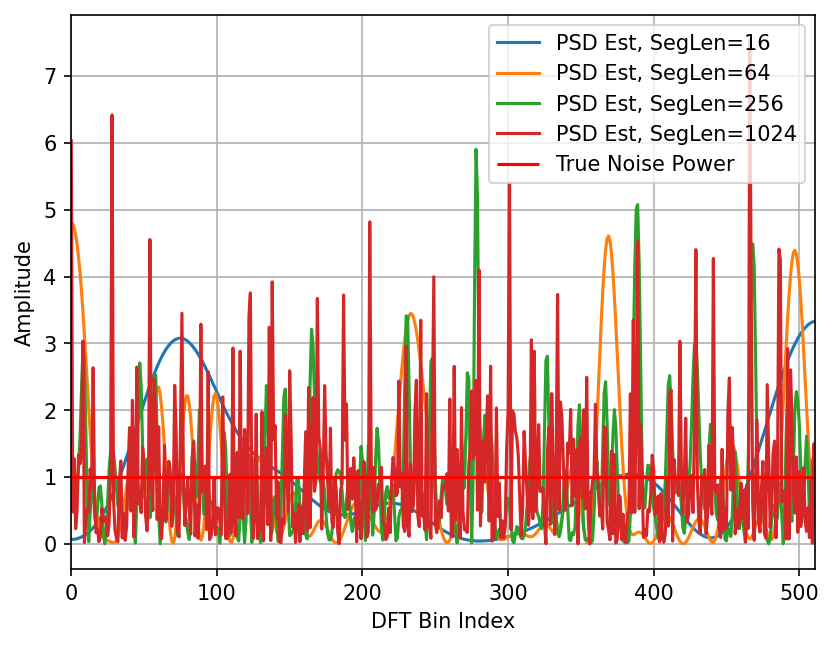

In [74]:
rng = np.random.default_rng()

Q = 1024
x = rng.uniform(low=-math.sqrt(3), high=math.sqrt(3), size=Q)
# x = rng.normal(loc=0, scale=1, size=Q)

Ls = [16, 64, 256, 1024]

fig, axs = plt.subplots(nrows=len(Ls), dpi=150, sharex=True, figsize=(6, 12))
fig2, axs2 = plt.subplots(dpi=150)
for ldx, L in enumerate(Ls):
    x_fft = fft.fft(np.concatenate((x[:L], np.zeros(Q-L, dtype="float"))))
    p = np.abs(x_fft[:round(Q/2)])**2/L
    axs[ldx].plot(p, label=f"PSD Est, SegLen={L}")
    axs[ldx].hlines([1], xmin=0, xmax=p.size-1, colors="r", label="True Noise Power")
    axs[ldx].set_ylabel(f"Amplitude")
    axs[ldx].legend()
    axs[ldx].grid()
    axs2.plot(p, label=f"PSD Est, SegLen={L}")

axs[ldx].set_xlim(left=0, right=p.size-1)
axs[ldx].set_xlabel("DFT Bin Index")

axs2.set_ylabel(f"Amplitude")
axs2.hlines([1], xmin=0, xmax=p.size-1, colors="r", label="True Noise Power")
axs2.set_xlim(left=0, right=p.size-1)
# axs2.set_ylim(bottom=0, top=8)
axs2.set_xlabel("DFT Bin Index")
axs2.legend(fontsize=10)
axs2.grid()

# Averaged periodogram for uniform white noise

L=1024, var=0.33144319281636075
L=256, var=-7.132197934527524
L=64, var=-13.92241281978164
L=16, var=-19.75554977852495


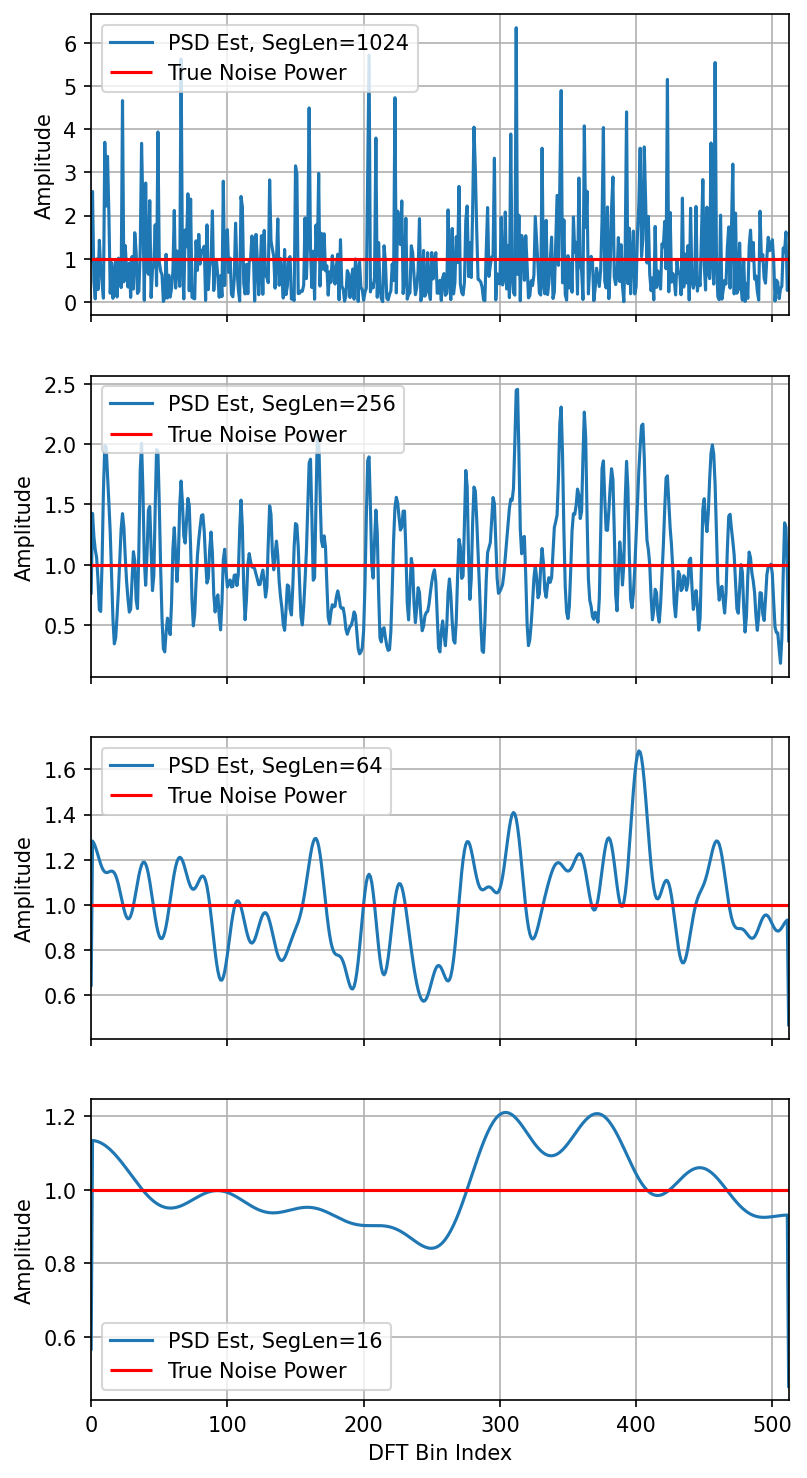

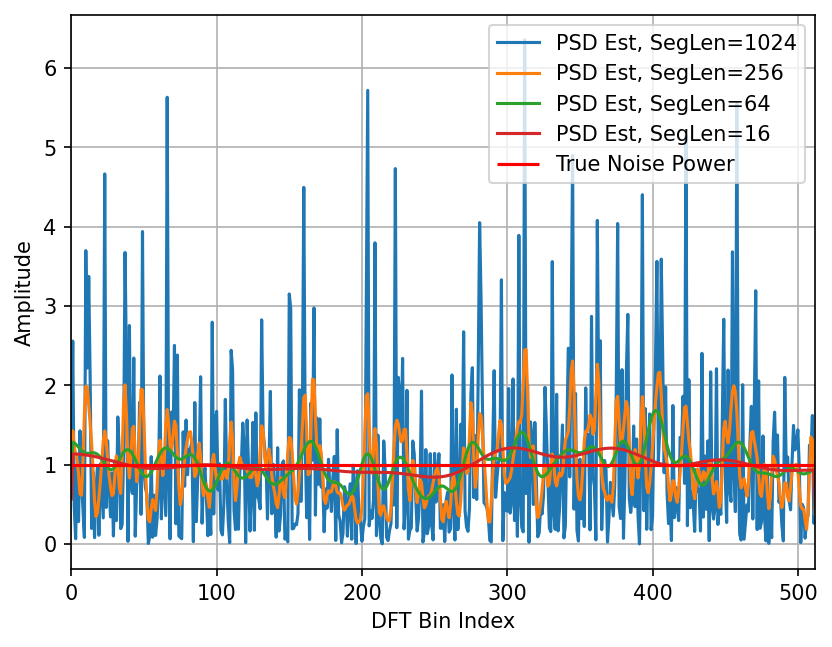

In [80]:
rng = np.random.default_rng()

A = 0.5
w0 = 2*np.pi/21
theta = rng.uniform(low=0, high=2*np.pi)
Q = 1024
# Q = 2**16 # Experiment with different record lengths
noise_var = 1

x = rng.uniform(low=-math.sqrt(3), high=math.sqrt(3), size=Q)

# fig, ax = plt.subplots(dpi=100)
# ax.stem(np.arange(x.size), x)
# ax.set_xlim(left=0, right=100)
# ax.set_xlabel("Sample Number")
# ax.set_ylabel("Amplitude")
# ax.grid()

Ls = [1024, 256, 64, 16]

fig, axs = plt.subplots(nrows=len(Ls), dpi=150, sharex=True, figsize=(6, 12))
fig2, axs2 = plt.subplots(dpi=150)
for ldx, L in enumerate(Ls):
    f, p = signal.welch(x, window="boxcar", nperseg=L, nfft=Q, detrend=False)
    axs[ldx].plot(p/2, label=f"PSD Est, SegLen={L}") # divide by 2 to normalize back to two-sided PSD level (but plot only one side)
    # axs[ldx].plot(10*np.log10(p/2), label=f"PSD Est, SegLen={L}") # divide by 2 to normalize back to two-sided PSD level (but plot only one side)
    axs[ldx].hlines([1], xmin=0, xmax=p.size-1, colors="r", label="True Noise Power")
    axs[ldx].set_ylabel(f"Amplitude")
    axs[ldx].legend()
    axs[ldx].grid()
    axs2.plot(p/2, label=f"PSD Est, SegLen={L}") # divide by 2 to normalize back to two-sided PSD level (but plot only one side)
    print(f"L={L}, var={10*np.log10((p/2).var())}")

axs[ldx].set_xlim(left=0, right=p.size-1)
axs[ldx].set_xlabel("DFT Bin Index")

axs2.set_ylabel(f"Amplitude")
axs2.hlines([1], xmin=0, xmax=p.size-1, colors="r", label="True Noise Power")
axs2.set_xlim(left=0, right=p.size-1)
# axs2.set_ylim(bottom=0, top=8)
axs2.set_xlabel("DFT Bin Index")
axs2.legend(fontsize=10)
axs2.grid()

# Averaged periodogram for sinusoid in uniform white noise

This example is from Discrete-Time Signal Processing (Oppenheim) Section 10.5.5.

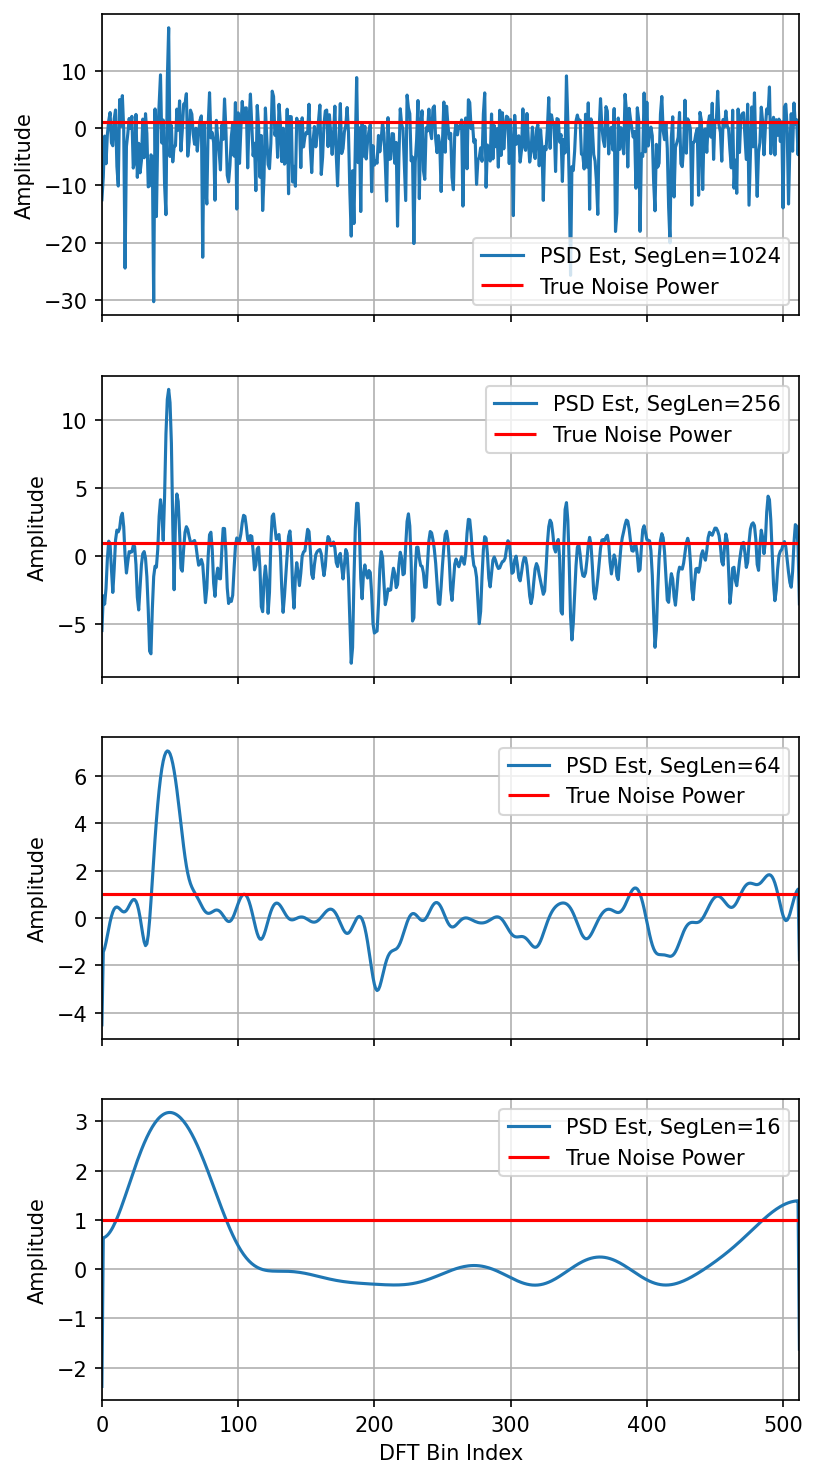

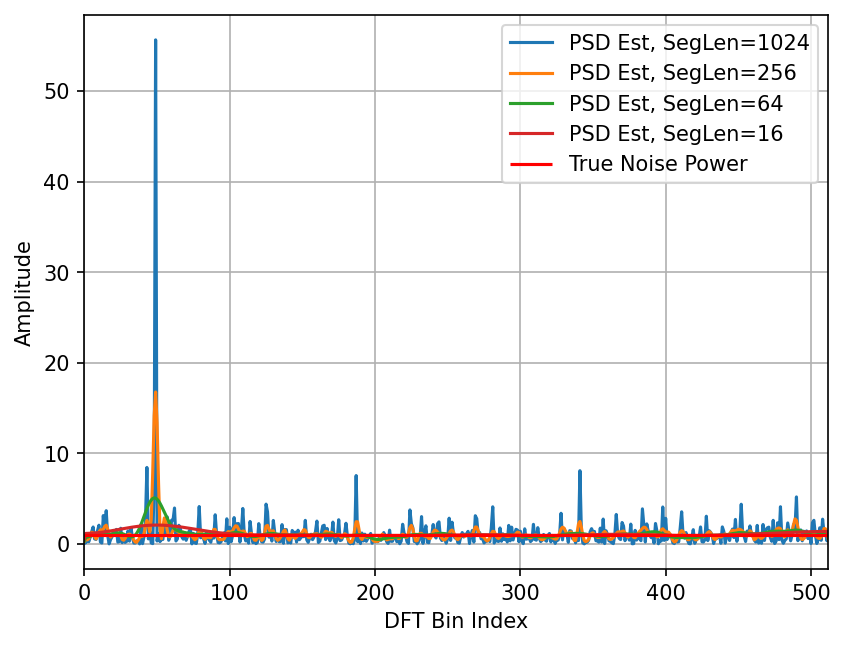

In [76]:
rng = np.random.default_rng()

A = 0.5
w0 = 2*np.pi/21
theta = rng.uniform(low=0, high=2*np.pi)
Q = 1024
# Q = 2**16 # Experiment with different record lengths
noise_var = 1

tone = A*np.cos(w0*np.arange(Q, dtype="float") + theta)
# tone = tone/4 # Experiment with different tone powers
# e = rng.normal(loc=0, scale=math.sqrt(noise_var), size=Q)
e = rng.uniform(low=-math.sqrt(3), high=math.sqrt(3), size=Q)
x = tone + e

# fig, ax = plt.subplots(dpi=100)
# ax.stem(np.arange(x.size), x)
# ax.set_xlim(left=0, right=100)
# ax.set_xlabel("Sample Number")
# ax.set_ylabel("Amplitude")
# ax.grid()

Ls = [1024, 256, 64, 16]

fig, axs = plt.subplots(nrows=len(Ls), dpi=150, sharex=True, figsize=(6, 12))
fig2, axs2 = plt.subplots(dpi=150)
for ldx, L in enumerate(Ls):
    f, p = signal.welch(x, window="boxcar", nperseg=L, nfft=Q, detrend=False)
    # axs[ldx].plot(p/2, label=f"PSD Est, SegLen={L}") # divide by 2 to normalize back to two-sided PSD level (but plot only one side)
    axs[ldx].plot(10*np.log10(p/2), label=f"PSD Est, SegLen={L}") # divide by 2 to normalize back to two-sided PSD level (but plot only one side)
    axs[ldx].hlines([1], xmin=0, xmax=p.size-1, colors="r", label="True Noise Power")
    axs[ldx].set_ylabel(f"Amplitude")
    axs[ldx].legend()
    axs[ldx].grid()
    axs2.plot(p/2, label=f"PSD Est, SegLen={L}") # divide by 2 to normalize back to two-sided PSD level (but plot only one side)

axs[ldx].set_xlim(left=0, right=p.size-1)
axs[ldx].set_xlabel("DFT Bin Index")

axs2.set_ylabel(f"Amplitude")
axs2.hlines([1], xmin=0, xmax=p.size-1, colors="r", label="True Noise Power")
axs2.set_xlim(left=0, right=p.size-1)
# axs2.set_ylim(bottom=0, top=8)
axs2.set_xlabel("DFT Bin Index")
axs2.legend(fontsize=10)
axs2.grid()